In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate total sales per week across all stores
daily = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
daily.columns = ['ds', 'y']  # Prophet requires exactly these column names

print("Data shape:", daily.shape)
print(daily.head())
print("\nDate range:", daily['ds'].min(), "to", daily['ds'].max())

Importing plotly failed. Interactive plots will not work.


Data shape: (143, 2)
          ds            y
0 2010-02-05  49750740.50
1 2010-02-12  48336677.63
2 2010-02-19  48276993.78
3 2010-02-26  43968571.13
4 2010-03-05  46871470.30

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


In [2]:
# Split: train on 80%, test on last 20%
split_index = int(len(daily) * 0.8)
train = daily[:split_index]
test = daily[split_index:]

print(f"Train size: {len(train)} weeks")
print(f"Test size: {len(test)} weeks")

# Build and train Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,  # we have weekly data, not daily
    daily_seasonality=False,
    seasonality_mode='multiplicative'  # better for retail sales
)

model.fit(train)
print("\nModel trained successfully")

Train size: 114 weeks
Test size: 29 weeks


16:51:48 - cmdstanpy - INFO - Chain [1] start processing
16:51:49 - cmdstanpy - INFO - Chain [1] done processing



Model trained successfully


In [4]:
# Predict
future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

# Fix: merge test with forecast on date to align properly
test_eval = test.copy()
test_eval = test_eval.merge(forecast[['ds', 'yhat']], on='ds', how='inner')

print(f"Matched test rows: {len(test_eval)}")

mae = mean_absolute_error(test_eval['y'].values, test_eval['yhat'].values)
rmse = np.sqrt(mean_squared_error(test_eval['y'].values, test_eval['yhat'].values))
avg_actual = test_eval['y'].mean()
accuracy = 100 - (mae / avg_actual * 100)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"Avg Actual Sales: ${avg_actual:,.0f}")
print(f"Model Accuracy: {accuracy:.1f}%")

Matched test rows: 0


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [5]:
# Check the date formats
print("Test dates sample:")
print(test['ds'].head())
print("Type:", test['ds'].dtype)

print("\nForecast dates sample:")
print(forecast['ds'].head())
print("Type:", forecast['ds'].dtype)

Test dates sample:
114   2012-04-13
115   2012-04-20
116   2012-04-27
117   2012-05-04
118   2012-05-11
Name: ds, dtype: datetime64[ns]
Type: datetime64[ns]

Forecast dates sample:
0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: ds, dtype: datetime64[ns]
Type: datetime64[ns]


In [6]:
# Normalize both to date only (remove time component) for matching
forecast['ds_date'] = forecast['ds'].dt.normalize()
test['ds_date'] = test['ds'].dt.normalize()

test_eval = test.merge(forecast[['ds_date', 'yhat']], on='ds_date', how='inner')
print(f"Matched test rows: {len(test_eval)}")

if len(test_eval) == 0:
    # Check what days of week each uses
    print("Test day of week:", test['ds'].dt.dayofweek.value_counts())
    print("Forecast day of week:", forecast['ds'].dt.dayofweek.value_counts())
else:
    mae = mean_absolute_error(test_eval['y'].values, test_eval['yhat'].values)
    rmse = np.sqrt(mean_squared_error(test_eval['y'].values, test_eval['yhat'].values))
    avg_actual = test_eval['y'].mean()
    accuracy = 100 - (mae / avg_actual * 100)
    print(f"MAE:  ${mae:,.0f}")
    print(f"RMSE: ${rmse:,.0f}")
    print(f"Avg Actual Sales: ${avg_actual:,.0f}")
    print(f"Model Accuracy: {accuracy:.1f}%")

Matched test rows: 0
Test day of week: ds
4    29
Name: count, dtype: int64
Forecast day of week: ds
4    114
6     12
Name: count, dtype: int64


C:\Users\YASHI GILL\AppData\Local\Temp\ipykernel_30784\1279756496.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ds_date'] = test['ds'].dt.normalize()


In [7]:
# Retrain with explicit Friday frequency
future = model.make_future_dataframe(periods=12, freq='W-FRI')
forecast = model.predict(future)

# Now match directly
test_eval = test.merge(forecast[['ds', 'yhat']], on='ds', how='inner')
print(f"Matched test rows: {len(test_eval)}")

mae = mean_absolute_error(test_eval['y'].values, test_eval['yhat'].values)
rmse = np.sqrt(mean_squared_error(test_eval['y'].values, test_eval['yhat'].values))
avg_actual = test_eval['y'].mean()
accuracy = 100 - (mae / avg_actual * 100)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"Avg Actual Sales: ${avg_actual:,.0f}")
print(f"Model Accuracy: {accuracy:.1f}%")

Matched test rows: 12
MAE:  $1,285,860
RMSE: $1,536,256
Avg Actual Sales: $47,066,283
Model Accuracy: 97.3%


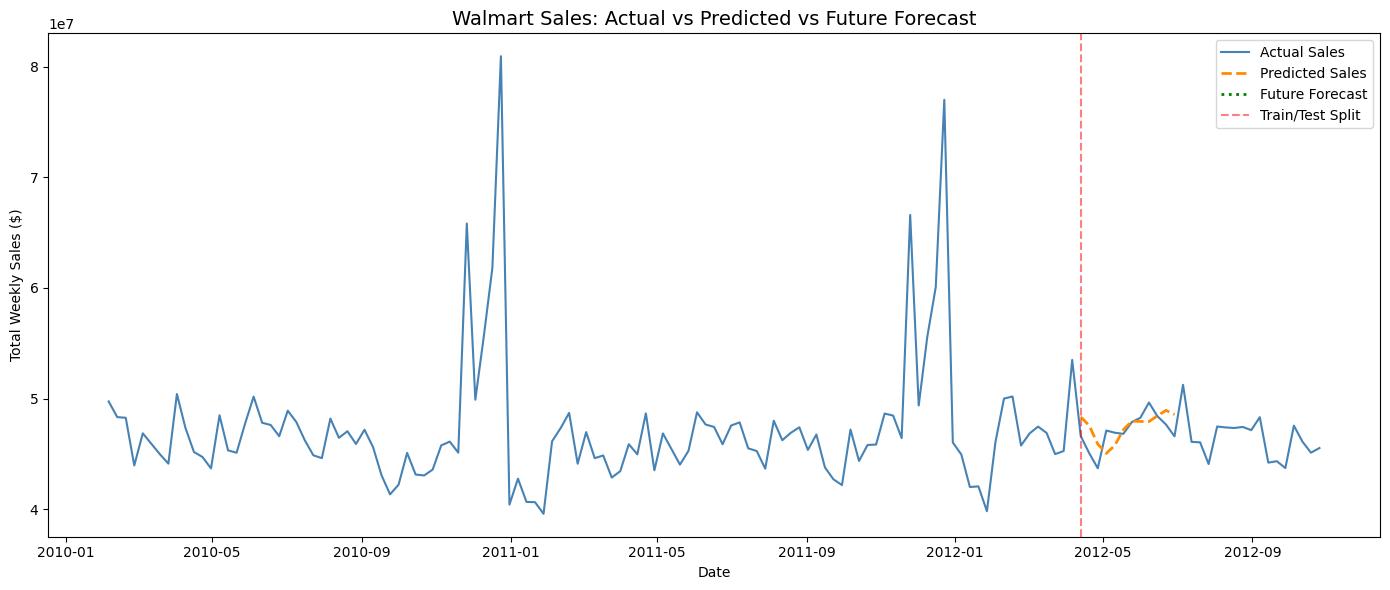

Chart saved


In [8]:
# Plot actual vs predicted
plt.figure(figsize=(14, 6))

# Actual values - full dataset
plt.plot(daily['ds'], daily['y'], label='Actual Sales', color='steelblue', linewidth=1.5)

# Predicted values on test period
plt.plot(test_eval['ds'], test_eval['yhat'], label='Predicted Sales', 
         color='darkorange', linewidth=2, linestyle='--')

# Future forecast (beyond actual data)
future_only = forecast[forecast['ds'] > daily['ds'].max()]
plt.plot(future_only['ds'], future_only['yhat'], label='Future Forecast', 
         color='green', linewidth=2, linestyle=':')

plt.axvline(x=test['ds'].min(), color='red', linestyle='--', alpha=0.5, label='Train/Test Split')

plt.title('Walmart Sales: Actual vs Predicted vs Future Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/06_forecast_vs_actual.png', dpi=150)
plt.show()
print("Chart saved")

In [9]:
# Save forecast results for Power BI
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_output.columns = ['Date', 'Predicted_Sales', 'Lower_Bound', 'Upper_Bound']

# Also merge actual values where available
actual = daily.copy()
actual.columns = ['Date', 'Actual_Sales']
final_output = forecast_output.merge(actual, on='Date', how='left')

final_output.to_csv('../outputs/forecast_results.csv', index=False)
print("Forecast results saved")
print(final_output.tail(15))

Forecast results saved
          Date  Predicted_Sales   Lower_Bound   Upper_Bound  Actual_Sales
111 2012-03-23     4.558823e+07  4.103611e+07  5.097569e+07   44993794.45
112 2012-03-30     4.615993e+07  4.119431e+07  5.142527e+07   45272862.02
113 2012-04-06     4.755143e+07  4.253316e+07  5.255326e+07   53502315.87
114 2012-04-13     4.835691e+07  4.360977e+07  5.346661e+07   46629261.41
115 2012-04-20     4.756905e+07  4.238341e+07  5.268335e+07   45072529.78
116 2012-04-27     4.590465e+07  4.080817e+07  5.134400e+07   43716798.89
117 2012-05-04     4.505725e+07  3.997250e+07  4.992128e+07   47124197.93
118 2012-05-11     4.578644e+07  4.082062e+07  5.102718e+07   46925878.99
119 2012-05-18     4.719602e+07  4.249084e+07  5.225034e+07   46823939.22
120 2012-05-25     4.797902e+07  4.307806e+07  5.274216e+07   47892463.31
121 2012-06-01     4.794248e+07  4.300385e+07  5.284852e+07   48281649.72
122 2012-06-08     4.793152e+07  4.276475e+07  5.294458e+07   49651171.78
123 2012-06-15 